# Difference-in-Differences Graph

## Imports and Data Loading

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
column_dtypes = {
    "code": str,
    "treatment": int,
    "year": int,
    "post": int,
    "poverty_indicator": int,
}

df = pd.read_csv("data/clean_hcv_data.csv", dtype=column_dtypes)
df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0


In [69]:
df.groupby(["year", "treatment"])["code"].nunique().unstack().rename(
    columns={0: "Control (Houston)", 1: "Treatment (Dallas)"}
)

treatment,Control (Houston),Treatment (Dallas)
year,,
2014,344,319
2015,343,306
2016,340,297
2017,345,286
2018,347,277
2019,351,279
2020,357,278
2021,342,273
2022,358,261


## 1. Plot Style

In [70]:
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

color_treat = "#D55E00"
color_ctrl = "#0072B2"

## 2. Difference-in-Differences Graph

In [71]:
agg = (
    df.groupby(["year", "treatment"])["number_reported"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg["se"] = agg["std"] / np.sqrt(agg["count"])
agg["ci_low"] = agg["mean"] - 1.96 * agg["se"]
agg["ci_high"] = agg["mean"] + 1.96 * agg["se"]
agg["group"] = agg["treatment"].map({0: "Control (Houston)", 1: "Treatment (Dallas)"})
agg

,year,treatment,mean,std,count,se,ci_low,ci_high,group
0,2014,0,61.561047,58.040217,344,3.129319,55.427582,67.694511,Control (Houston)
1,2014,1,76.564263,83.737957,319,4.688425,67.374949,85.753577,Treatment (Dallas)
2,2015,0,61.600583,59.924765,343,3.235633,55.258742,67.942424,Control (Houston)
3,2015,1,81.297386,89.844674,306,5.136078,71.230672,91.364099,Treatment (Dallas)
4,2016,0,64.229412,64.328987,340,3.488729,57.391503,71.067321,Control (Houston)
5,2016,1,81.232323,91.162036,297,5.289758,70.864398,91.600249,Treatment (Dallas)
6,2017,0,63.675362,63.959508,345,3.443464,56.926173,70.424552,Control (Houston)
7,2017,1,78.297203,87.034531,286,5.146460,68.210142,88.384264,Treatment (Dallas)
8,2018,0,63.691643,65.074035,347,3.493357,56.844662,70.538623,Control (Houston)
9,2018,1,78.263538,88.012552,277,5.288162,67.898741,88.628335,Treatment (Dallas)


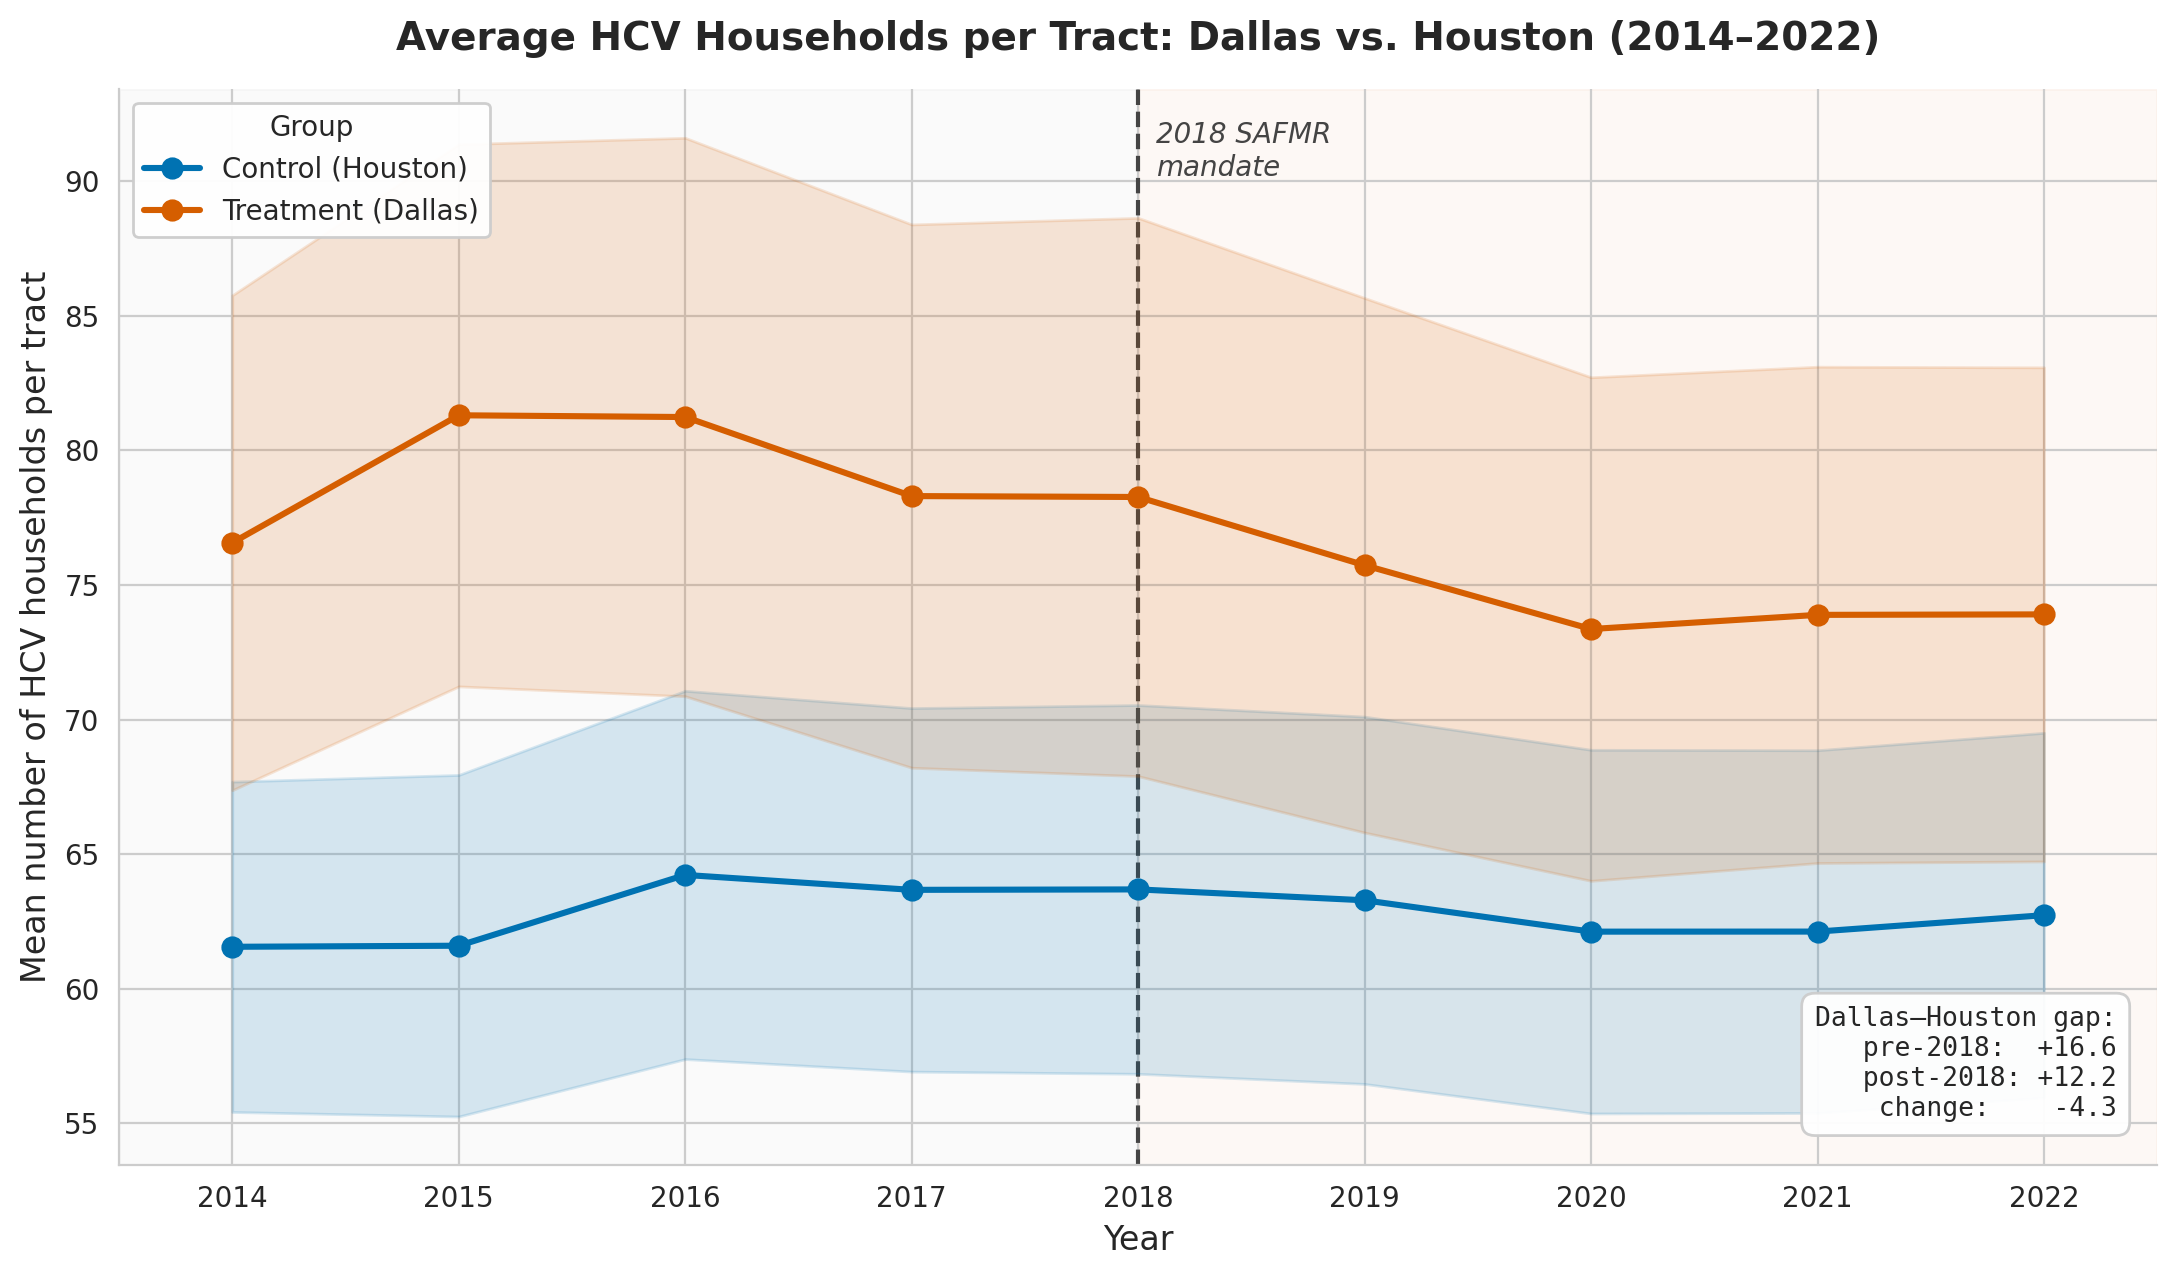

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

for _, group_label, color in [
    (0, "Control (Houston)", color_ctrl),
    (1, "Treatment (Dallas)", color_treat),
]:
    sub = agg[agg["group"] == group_label].sort_values("year")
    ax.plot(
        sub["year"],
        sub["mean"],
        marker="o",
        linewidth=2.2,
        markersize=7,
        color=color,
        label=group_label,
        zorder=3,
    )
    ax.fill_between(
        sub["year"],
        sub["ci_low"],
        sub["ci_high"],
        color=color,
        alpha=0.15,
        zorder=2,
    )

# 2018 SAFMR mandate vertical line
policy_year = 2018
ax.axvline(policy_year, color="#444444", linestyle="--", linewidth=1.5, zorder=1)

ymin, ymax = ax.get_ylim()
ax.text(
    policy_year + 0.08,
    ymax - (ymax - ymin) * 0.03,
    "2018 SAFMR\nmandate",
    fontsize=10,
    color="#444444",
    va="top",
    ha="left",
    style="italic",
)

# Light shading to distinguish pre and post regions
ax.axvspan(agg["year"].min() - 0.5, policy_year, color="gray", alpha=0.04, zorder=0)
ax.axvspan(policy_year, agg["year"].max() + 0.5, color="#D55E00", alpha=0.04, zorder=0)

# Annotate the change in gap from pre to post, not the raw final-year difference.
# This is closer to the DiD idea: how much did the Dallas-Houston gap change after 2018?
pre_mask = agg["year"] < policy_year
post_mask = agg["year"] >= policy_year

treat_pre = agg.loc[pre_mask & (agg["treatment"] == 1), "mean"].mean()
ctrl_pre = agg.loc[pre_mask & (agg["treatment"] == 0), "mean"].mean()
treat_post = agg.loc[post_mask & (agg["treatment"] == 1), "mean"].mean()
ctrl_post = agg.loc[post_mask & (agg["treatment"] == 0), "mean"].mean()

gap_pre = treat_pre - ctrl_pre
gap_post = treat_post - ctrl_post
gap_change = gap_post - gap_pre   

ax.text(
    0.98,
    0.04,
    f"Dallas\u2013Houston gap:\n  pre-2018:  {gap_pre:+.1f}\n  post-2018: {gap_post:+.1f}\n  change:    {gap_change:+.1f}",
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom",
    ha="right",
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc", alpha=0.95
    ),
)

ax.set_title(
    "Average HCV Households per Tract: Dallas vs. Houston (2014\u20132022)",
    pad=14,
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean number of HCV households per tract")
ax.set_xticks(sorted(agg["year"].unique()))
ax.legend(
    title="Group",
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    edgecolor="#cccccc",
)

ax.set_xlim(agg["year"].min() - 0.5, agg["year"].max() + 0.5)

plt.tight_layout()
plt.show()

### Description

This figure shows the average number of HCV households per tract in Dallas (treatment) and Houston (control) from 2014 to 2022. The dashed line marks 2018, when the SAFMR mandate took effect, and the shaded bands are 95% confidence intervals on each yearly group mean.

Dallas tracts sit consistently above Houston tracts across the whole panel. Before 2018, both series are fairly stable — Houston stays around 62–64 and Dallas moves between roughly 76 and 81, peaking at about 81 in 2015–2016 and falling back to around 78 by 2017. The two lines are not perfectly parallel but track each other reasonably well in this window.

After 2018 the two series pull apart. Dallas drops more sharply and keeps falling through 2020, while Houston stays close to its pre-2018 level. The summary box in the lower right shows this directly: the Dallas–Houston gap was about +16.6 households per tract before 2018 and narrows to about +12.2 after, a change of roughly −4.3.